<a href="https://colab.research.google.com/github/mamgezet-tech/Praktikum-Struktur-Data-1/blob/main/Prak10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


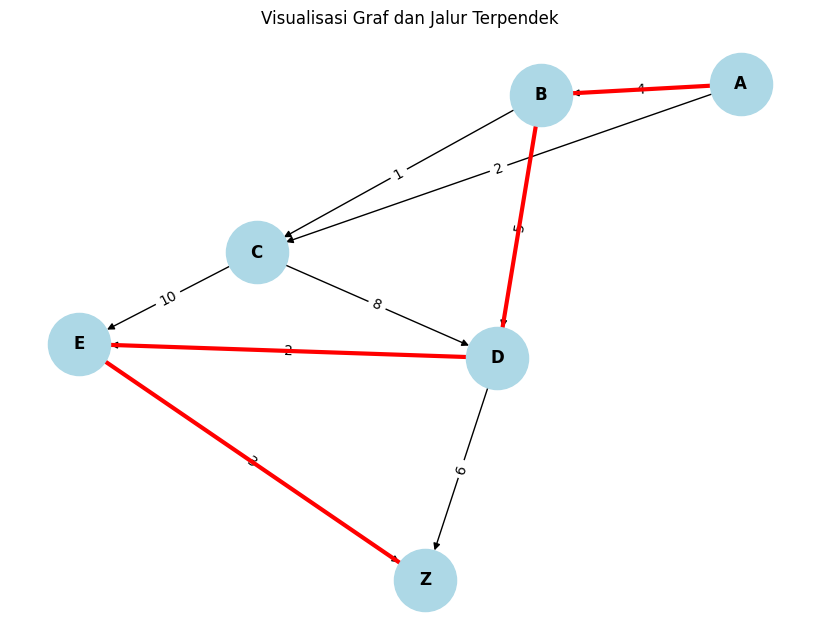

In [6]:
# 1. Instalasi library
!pip install networkx matplotlib

import heapq
import networkx as nx
import matplotlib.pyplot as plt
# 2. Mengimplementasikan struktur data graf dan memodifikasi algoritma Dijkstra
def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].items():
      new_distance = current_distance + weight
      if new_distance < distances[neighbor]:
        distances[neighbor] = new_distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (new_distance, neighbor))

  return distances, previous

# 3. Merekonstruksi jalur
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

# 4. Visualisasi dengan networkx dan matplotlib
def visualice_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)
  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len(path) > 1:
      path_edges = list(zip(path, path[1:]))
      nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

# 5. Penggunaan lengkap
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualice_graph(graph, path=shortest_path)


Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


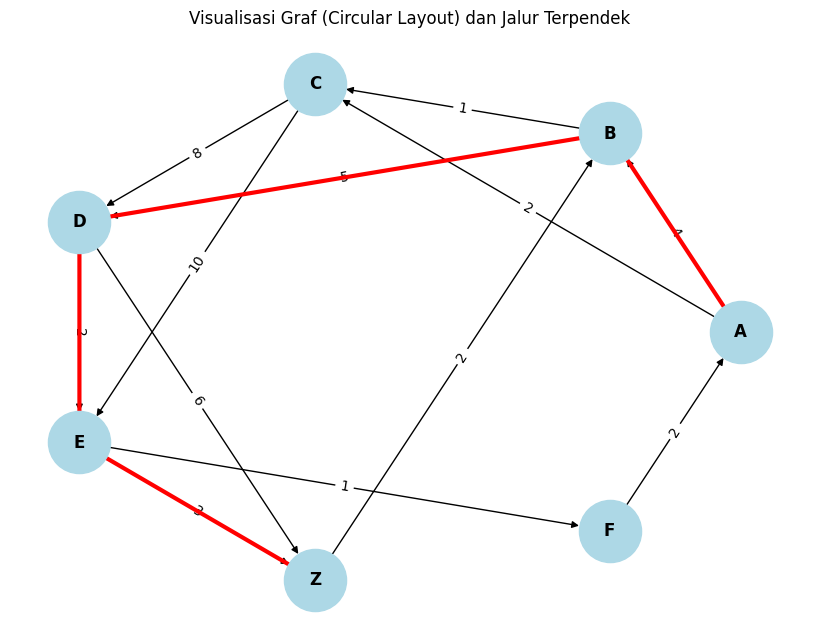

In [8]:
# tugas
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNGSI ALGORITMA DIJKSTRA
# ==========================================
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        # Antisipasi jika ada simpul yang tidak memiliki tetangga keluar
        if current_node not in graph: # Fix: Removed 'invite'
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# ==========================================
# 2. FUNGSI REKONSTRUKSI JALUR
# ==========================================
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous.get(target) # Menggunakan .get() agar aman dari KeyError
    return path

# ==========================================
# 3. FUNGSI VISUALISASI GRAF (DENGAN TATA LETAK BARU)
# ==========================================
def visualize_graph(graph, path=None):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # --- PERUBAHAN POIN 3: Mengganti tata letak menjadi circular_layout ---
    # Kamu juga bisa menggantinya dengan: pos = nx.kamada_kawai_layout(G)
    pos = nx.circular_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf (Circular Layout) dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# ==========================================
# 4. DEFINISI DATA & EKSEKUSI (MODIFIKASI POIN 1 & 2)
# ==========================================
# Graf yang sudah dimodifikasi
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'F': 1},   # Menghubungkan ke simpul baru 'F'
    'F': {'A': 2},           # --- PERUBAHAN POIN 1: Membuat SIKLUS (F kembali ke A) ---
    'Z': {'B': 2}            # --- PERUBAHAN POIN 1: Membuat SIKLUS (Z kembali ke B) ---
}

# --- PERUBAHAN POIN 2: Menambahkan simpul baru 'F' ke dalam struktur graf ---
# (Simpul F sudah didefinisikan di dalam struktur 'graph' di atas)

# Jalankan Dijkstra dari 'A' ke 'Z'
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi hasil akhir
visualize_graph(graph, path=shortest_path)


Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


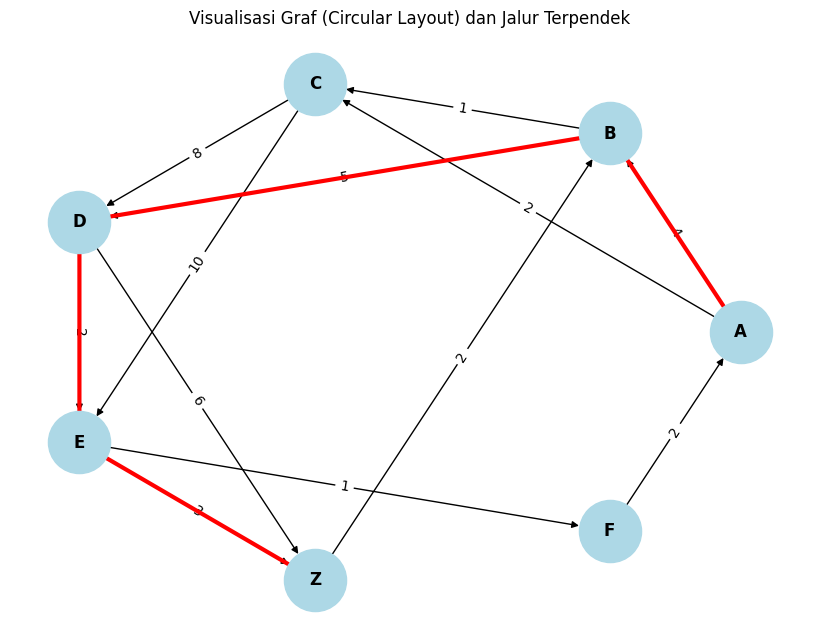

In [9]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNGSI ALGORITMA DIJKSTRA (Gambar ke-3)
# ==========================================
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        # Antisipasi jika ada simpul yang tidak memiliki tetangga keluar
        if current_node not in graph:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# ==========================================
# 2. FUNGSI REKONSTRUKSI JALUR
# ==========================================
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous.get(target) # Menggunakan .get() agar aman jika ada siklus balik
    return path

# ==========================================
# 3. FUNGSI VISUALISASI GRAF (Gambar ke-1 + Modifikasi Tugas)
# ==========================================
def visualize_graph(graph, path=None):
    # Menggunakan DiGraph (Directed Graph) agar arah panah sesuai dengan data graph asli
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Menggunakan circular_layout sesuai dengan instruksi tugas/latihan
    pos = nx.circular_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    # Menggambar semua node dan edge asli sesuai instruksi Gambar 1
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal untuk jalur terpendek (Logika asli Gambar 1)
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        # Ditambahkan edgelist=path_edges agar hanya rute terpendek yang diwarnai merah tebal
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3, arrows=True)

    plt.title("Visualisasi Graf (Circular Layout) dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# Graf yang sudah dimodifikasi sesuai tugas (memiliki siklus dan simpul F)
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'F': 1},   # Ditambah simpul baru F
    'F': {'A': 2},           # Siklus balik ke A
    'Z': {'B': 2}            # Siklus balik ke B
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


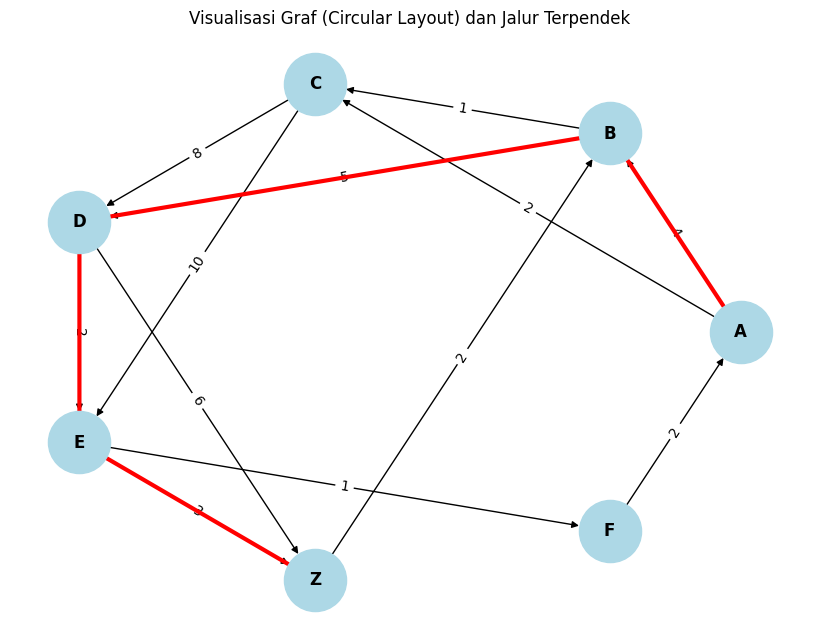

In [11]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if current_node not in graph:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous.get(target)
    return path

def visualize_graph(graph, path=None):
    # Menggunakan DiGraph (Directed Graph)
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Menggunakan circular_layout
    pos = nx.circular_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3, arrows=True)

    plt.title("Visualisasi Graf (Circular Layout) dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# Graf yang sudah dimodifikasi (memiliki siklus dan simpul F)
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'F': 1},   # tambah simpul baru F
    'F': {'A': 2},           # Siklus balik ke A
    'Z': {'B': 2}            # Siklus balik ke B
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)